<a href="https://colab.research.google.com/github/krushna1133/NNDL-Practical/blob/main/NNDL_Practical5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

TensorFlow Version: 2.20.0
228813984/228813984 ━━━━━━━━━━━━━━━━━━━━ 13s 0us/step
Dataset location: /root/.keras/datasets/flower_photos
Found 3670 files belonging to 1 classes.
Using 2936 files for training.
Found 3670 files belonging to 1 classes.
Using 734 files for validation.

Flower Classes:
0 : flower_photos

Number of Classes: 1


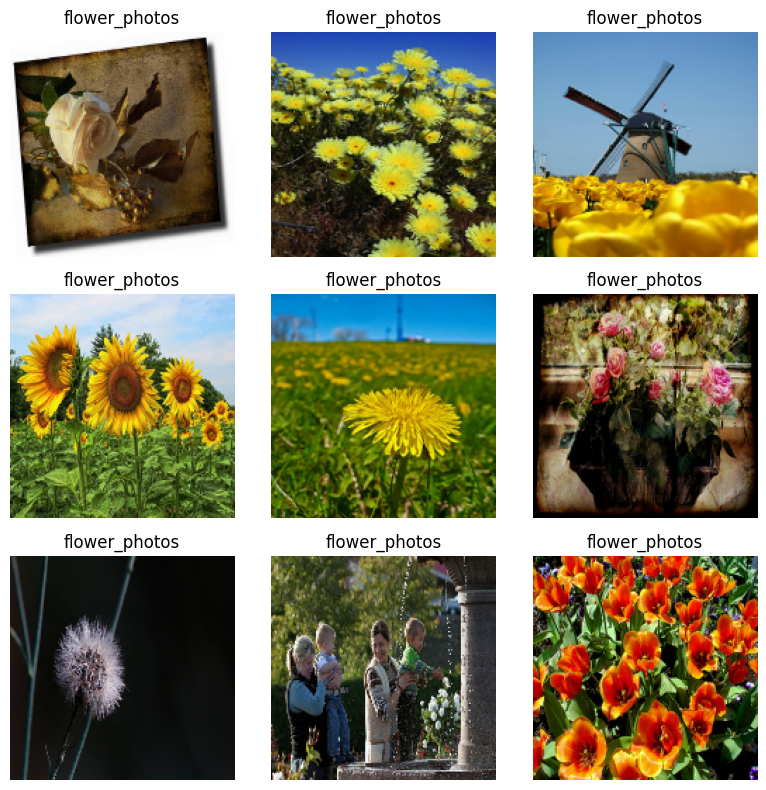

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_160            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

...

Epoch 1/5


/usr/local/lib/python3.13/dist-packages/keras/src/ops/nn.py:947: UserWarning: You are using a softmax over axis -1 of a tensor of shape (None, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


92/92 ━━━━━━━━━━━━━━━━━━━━ 54s 389ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 2/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 7s 76ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 3/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 5s 55ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 4/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 69ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 5/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 9s 55ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.0000e+00 - val_loss: 0.0000e+00
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00

--------------------------------
Validation Loss: 0.0
Validation Accuracy: 0.0
--------------------------------
Accuracy Percentage: 0.0 %


/usr/local/lib/python3.13/dist-packages/keras/src/ops/nn.py:947: UserWarning: You are using a softmax over axis -1 of a tensor of shape (32, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(



--------------------------------
Predicted: flower_photos
Actual: flower_photos
--------------------------------


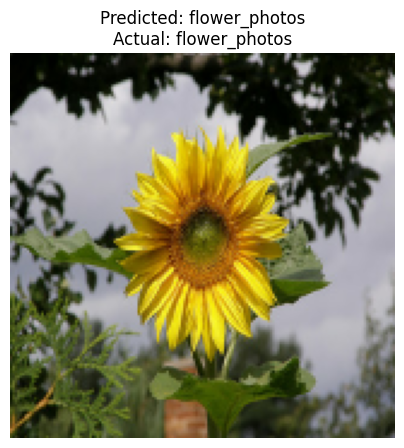

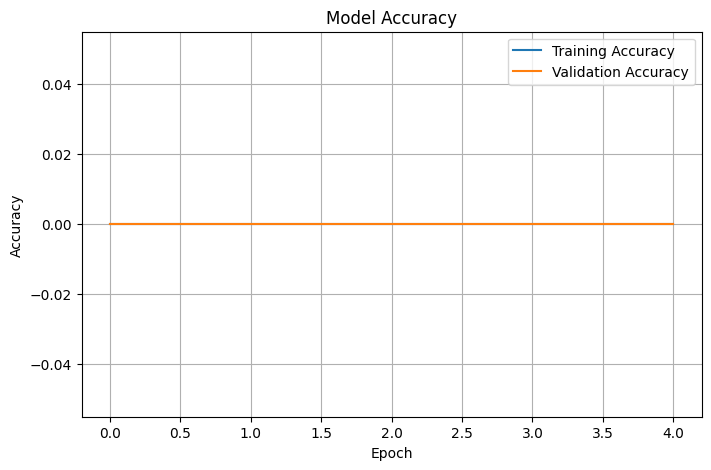

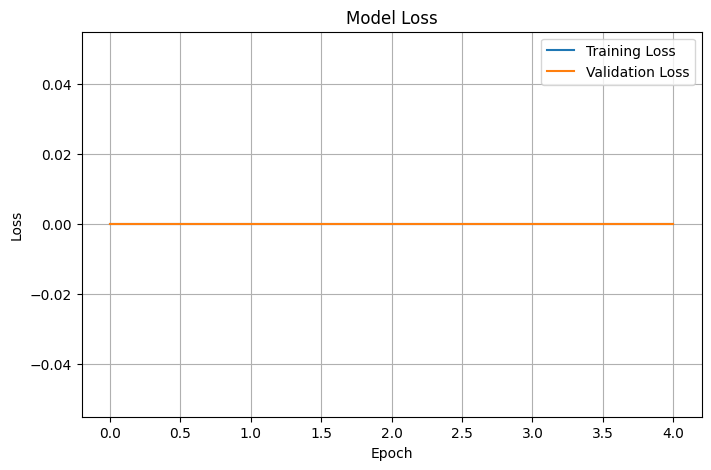


TRANSFER LEARNING EXPERIMENT COMPLETED
Dataset       : TF Flowers
Model         : MobileNetV2
Image Size    : 160 x 160
Batch Size    : 32
Epochs        : 5
Classes       : 1
Accuracy      : 0.0 %


In [2]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import os

from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input


print("TensorFlow Version:", tf.__version__)


dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"

data_dir = tf.keras.utils.get_file(
    "flower_photos",
    origin=dataset_url,
    untar=True
)

print("Dataset location:", data_dir)



IMG_SIZE = (160, 160)
BATCH_SIZE = 32
SEED = 123

train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.20,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

validation_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.20,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)


class_names = train_ds.class_names

print("\nFlower Classes:")

for i, name in enumerate(class_names):
    print(i, ":", name)

print("\nNumber of Classes:", len(class_names))



plt.figure(figsize=(8, 8))

for images, labels in train_ds.take(1):

    for i in range(9):

        plt.subplot(3, 3, i + 1)

        plt.imshow(images[i].numpy().astype("uint8"))

        plt.title(class_names[labels[i].numpy()])

        plt.axis("off")

plt.tight_layout()
plt.show()



def preprocess_dataset(images, labels):

    images = tf.cast(images, tf.float32)

    images = preprocess_input(images)

    return images, labels


train_ds = train_ds.map(
    preprocess_dataset,
    num_parallel_calls=tf.data.AUTOTUNE
)

validation_ds = validation_ds.map(
    preprocess_dataset,
    num_parallel_calls=tf.data.AUTOTUNE
)



train_ds = train_ds.prefetch(tf.data.AUTOTUNE)

validation_ds = validation_ds.prefetch(tf.data.AUTOTUNE)



base_model = MobileNetV2(
    input_shape=(160, 160, 3),
    include_top=False,
    weights="imagenet"
)


# Freeze pretrained layers

base_model.trainable = False



model = Sequential([

    base_model,

    layers.GlobalAveragePooling2D(),

    layers.Dense(
        128,
        activation="relu"
    ),

    layers.Dropout(0.3),

    layers.Dense(
        len(class_names),
        activation="softmax"
    )
])



model.summary()



model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


EPOCHS = 5

history = model.fit(
    train_ds,
    validation_data=validation_ds,
    epochs=EPOCHS
)


loss, accuracy = model.evaluate(validation_ds)

print("\n--------------------------------")
print("Validation Loss:", loss)
print("Validation Accuracy:", accuracy)
print("--------------------------------")

print(
    "Accuracy Percentage:",
    round(accuracy * 100, 2),
    "%"
)



for images, labels in validation_ds.take(1):

    predictions = model.predict(images, verbose=0)

    predicted_class = np.argmax(predictions[0])

    actual_class = labels[0].numpy()

    print("\n--------------------------------")
    print(
        "Predicted:",
        class_names[predicted_class]
    )

    print(
        "Actual:",
        class_names[actual_class]
    )

    print("--------------------------------")



plt.figure(figsize=(5, 5))


display_image = (images[0].numpy() + 1.0) / 2.0

plt.imshow(display_image)

plt.title(
    "Predicted: "
    + class_names[predicted_class]
    + "\nActual: "
    + class_names[actual_class]
)

plt.axis("off")

plt.show()



plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("Model Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.grid(True)

plt.show()


plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title("Model Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.grid(True)

plt.show()


print("\n========================================")
print("TRANSFER LEARNING EXPERIMENT COMPLETED")
print("========================================")

print("Dataset       : TF Flowers")
print("Model         : MobileNetV2")
print("Image Size    : 160 x 160")
print("Batch Size    :", BATCH_SIZE)
print("Epochs        :", EPOCHS)
print("Classes       :", len(class_names))
print("Accuracy      :", round(accuracy * 100, 2), "%")

print("========================================")